In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
iris = datasets.load_iris()

In [3]:
X = iris.data
y = iris.target


In [4]:
X = X[y!=2]
y = y[y!=2]

In [5]:
X = X[:, :2]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

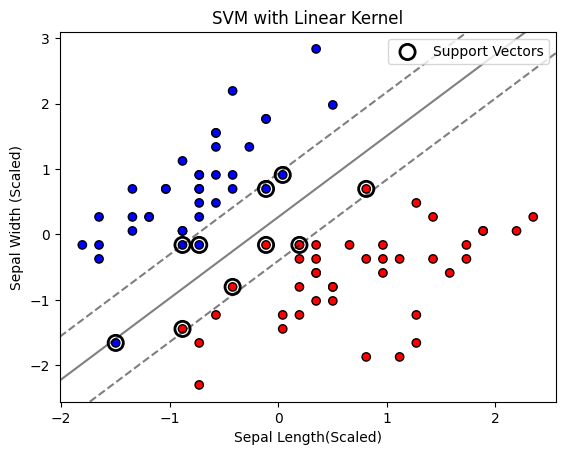

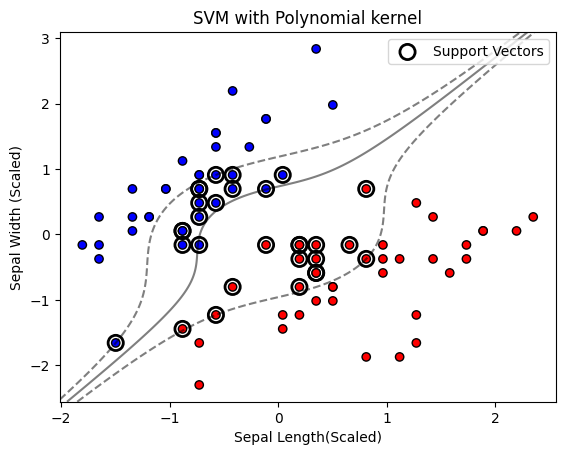

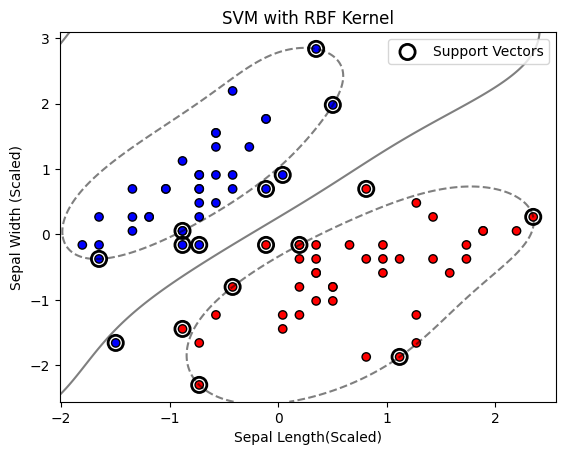

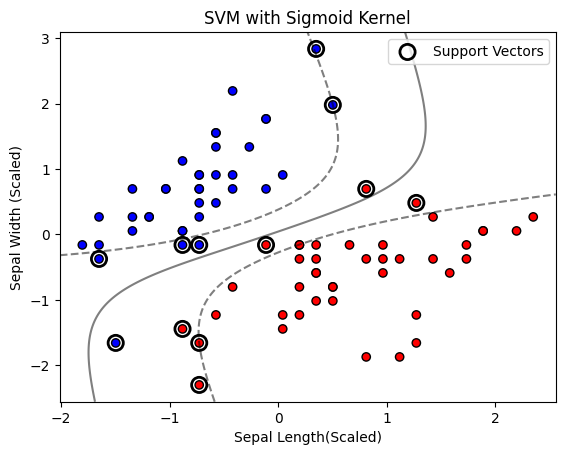

In [9]:
def plot_hyperplane(X,y,model,title) :

  plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr', edgecolors='k')
  ax = plt.gca()
  xlim = ax.get_xlim()
  ylim = ax.get_ylim()

  xx = np.linspace(xlim[0], xlim[1], 500)
  yy = np.linspace(ylim[0], ylim[1], 500)

  YY, XX = np.meshgrid(yy, xx)
  xy = np.vstack([XX.ravel(),YY.ravel()]).T

  Z = model.decision_function(xy).reshape(XX.shape)

  ax.contour(XX, YY, Z,
             colors='k',
             levels=[-1, 0, 1],
             alpha=0.5,
             linestyles=['--', '-', '--']
             )

  support_vectors = model.support_vectors_
  ax.scatter(support_vectors[:,0],
             support_vectors[:, 1],
             s = 120, linewidth = 2,
             facecolors='none',
             edgecolors='k',
             label='Support Vectors'
             )

  plt.title(title)
  plt.xlabel('Sepal Length(Scaled)')
  plt.ylabel('Sepal Width (Scaled)')
  plt.legend()
  plt.show()



linear_model = SVC(
      kernel = 'linear',
      C=1
  )

linear_model.fit(X_train, y_train)

plot_hyperplane(X_train,
                y_train,
                linear_model,
                'SVM with Linear Kernel'
)

poly_model = SVC(
      kernel ='poly',
      degree=3,
      C=1,
      gamma ='scale'
)

poly_model.fit(X_train, y_train)

plot_hyperplane(X_train,
                y_train,
                poly_model,
                'SVM with Polynomial kernel'
)

rbf_model = SVC(
            kernel='rbf',
            C=1,
            gamma = 'scale'
)

rbf_model.fit(X_train, y_train)

plot_hyperplane(
      X_train,
      y_train,
      rbf_model,
      'SVM with RBF Kernel'
)

sigmoid_model = SVC(
      kernel='sigmoid',
      C=1,
      gamma='scale'
)

sigmoid_model.fit(X_train, y_train)

plot_hyperplane(X_train,
                  y_train,
                  sigmoid_model,
                  'SVM with Sigmoid Kernel'
)

